```
Universidade Federal de Sergipe
Centro de Ciências Exatas e Tecnologia
Departamento de Matemática
Álgebra Linear Computacional
Prof Evilson
```

##### Utilizando código sugestâo do professor

> Observação: Primeiro passo nessa parte do código


In [2]:
# Importando módulos para manipulação de matrizes
import numpy as np
from numpy import linalg as la
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import random

# Importando módulos para manipulação de imagens e gráficos
import glob
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Importando módulo do Perceptron
from sklearn.linear_model import Perceptron

# Seed fixa para reprodutibilidade dos resultados entre execuções
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [3]:
# funções

def plotar_foto(foto_lista):
    fig, ax = plt.subplots()
    foto = np.reshape(foto_lista, (193, 162))
    
    ax.imshow(foto, cmap='gray', vmin=0, vmax=255)
    plt.show()

def plotar_fotos(foto1_lista, foto2_lista):
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
    
    foto1 = np.reshape(foto1_lista, (193, 162))
    foto2 = np.reshape(foto2_lista, (193, 162))
    
    ax1.imshow(foto1, cmap='gray', vmin=0, vmax=255)
    ax2.imshow(foto2, cmap='gray', vmin=0, vmax=255)
    
    plt.show()

In [4]:
# Caminho para as imagens e criação da matriz
# Ajuste IMAGES_DIR para o caminho onde as imagens estão na sua máquina
IMAGES_DIR = Path("Imagens")
IMAGE_HEIGHT = 193
IMAGE_WIDTH = 162

file_names = sorted(glob.glob(str(IMAGES_DIR / "*.jpg")))
im_number = len(file_names)

matrix = np.empty([im_number, IMAGE_HEIGHT * IMAGE_WIDTH])

In [5]:
# Inserindo as fotos na matriz criada
for i in range(im_number // 2):

    image = Image.open(IMAGES_DIR / f'{i+1}a.jpg')
    array = np.asarray(image).ravel()
    matrix[2*i] = array

    image = Image.open(IMAGES_DIR / f'{i+1}b.jpg')
    array = np.asarray(image).ravel()
    matrix[2*i+1] = array

# Verificando a matriz
print(f'height = {matrix.shape[0]} | width = {matrix.shape[1]}')
print(matrix)

height = 400 | width = 31266
[[254. 252. 252. ...  65.  70.  70.]
 [250. 252. 252. ...  70.  76.  78.]
 [ 65.  52.  32. ...   0.   0.   0.]
 ...
 [ 76.  33.  39. ...   0.   0.   0.]
 [209. 209. 215. ... 133. 133. 163.]
 [220. 217. 217. ... 154. 158. 158.]]


-----------------------------------------------------------------

# Questões 

-----------------------------------------------------------------


Vetor médio [162.1675 161.3975 160.685  ...  60.89    61.8675  63.815 ] 



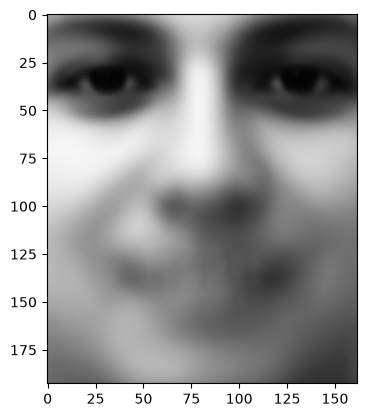

In [6]:
# Passo 2 para exibir a imagem média

im_media = np.mean(matrix, axis=0) 
print(f'\nVetor médio {im_media}', '\n')

plotar_foto(im_media)

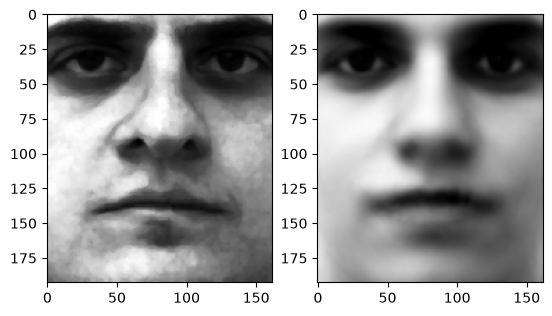

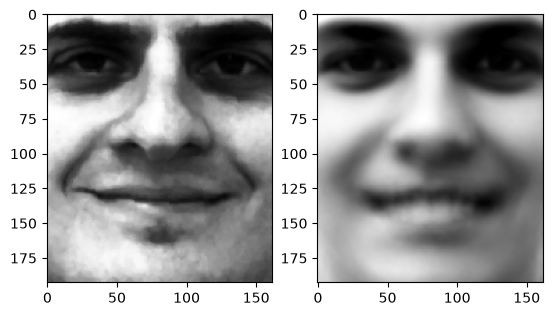

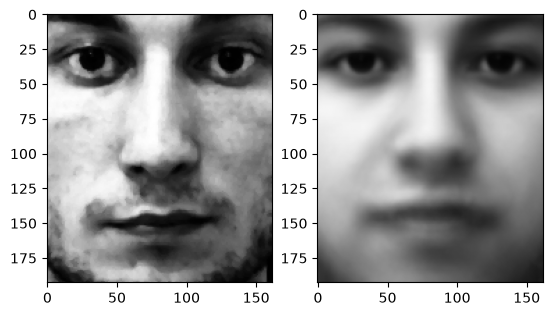

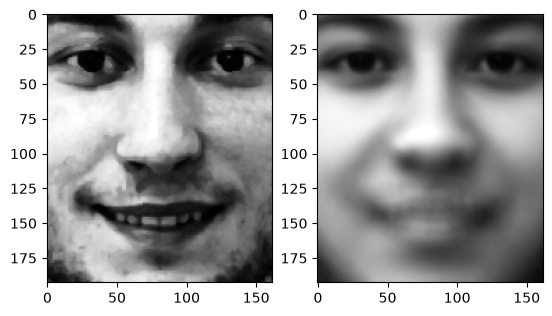

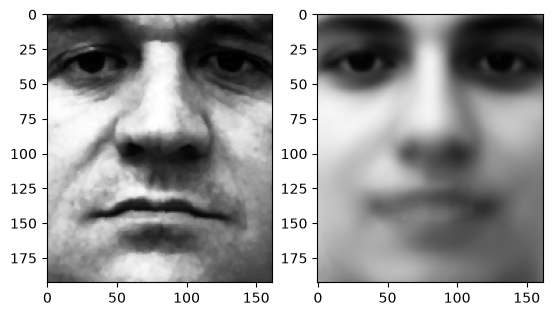

In [7]:
# Passos 3 e 4

M = matrix - im_media # Subtraindo a imagem média

U, S, Vh = la.svd(M, full_matrices=False) # Aplicando o SVD

k = 5 # Num de componentes e de fotos

fotos_reconstruidas = np.zeros((k, M.shape[1])) # Criando a matriz para armazenar "fotos novas"

for i in range(k):
    for j in range(k):
        fotos_reconstruidas[i] += U[i, j] * S[j] * Vh[j] # Aplicando os coeficientes(a_i = U[i,j] * S[j])
    fotos_reconstruidas[i] += im_media # Somando a imagem média para obter as fotos com as 5 componentes
    
    plotar_fotos(matrix[i, :], fotos_reconstruidas[i, :])

In [8]:
# Preparando para o treinamento do classificador
# Caminho para as imagens e criação da matriz de homens e mulheres
IMAGES_DIR_GEN = Path("Imagens/homens_mulheres")

file_names = sorted(glob.glob(str(IMAGES_DIR_GEN / "*.jpg")))
pic_number = len(file_names)

fotos_treinamento = np.empty([pic_number, IMAGE_HEIGHT * IMAGE_WIDTH])

# Inserindo as fotos na matriz criada
# Aqui o arquivo foi organizado para que as fotos de mulheres viessem após as fotos dos homens
for i in range(pic_number // 2):

    image = Image.open(IMAGES_DIR_GEN / f'{i+1}a.jpg')
    array = np.asarray(image).ravel()
    fotos_treinamento[2*i] = array

    image = Image.open(IMAGES_DIR_GEN / f'{i+1}b.jpg')
    array = np.asarray(image).ravel()
    fotos_treinamento[2*i+1] = array

In [9]:
# Rótulos de gênero: -1 = homem, 1 = mulher
# (fotos_treinamento foi organizado com todos os homens primeiro, depois as mulheres)
labels_genero = np.array([-1]*(pic_number//2) + [1]*(pic_number//2))

# Split treino/validação sobre as fotos com rótulo CONHECIDO,
# para conseguirmos medir a precisão de fato (e não só "olhar uma foto")
fotos_treino_gen, fotos_val_gen, labels_treino_gen, labels_val_gen = train_test_split(
    fotos_treinamento, labels_genero, test_size=0.25,
    stratify=labels_genero, random_state=RANDOM_STATE
)

# Conjunto de fotos fora de homens_mulheres: não temos o gênero verdadeiro delas,
# então servem só para demonstração visual, não para medir acurácia
mask_fora_treino = np.array([
    not any(np.array_equal(matrix[i], linha) for linha in fotos_treinamento)
    for i in range(im_number)
])
fotos_teste = matrix[mask_fora_treino]

Acurácia (3 componentes): 60.00%


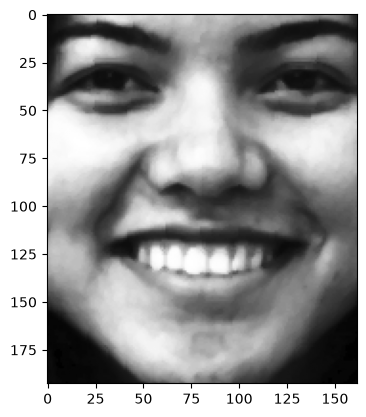

Mulher


In [10]:
# Perceptron com 3 componentes principais

svd_3c = TruncatedSVD(n_components=3, random_state=RANDOM_STATE)
svd_3c.fit(matrix)  # Componentes obtidas a partir de todas as fotos

dados_treino_3c = svd_3c.transform(fotos_treino_gen)
dados_val_3c = svd_3c.transform(fotos_val_gen)

clf_genero_3c = Perceptron(random_state=RANDOM_STATE)
clf_genero_3c.fit(dados_treino_3c, labels_treino_gen)

predicoes_val = clf_genero_3c.predict(dados_val_3c)
print(f"Acurácia (3 componentes): {accuracy_score(labels_val_gen, predicoes_val):.2%}")

# Demonstração em uma foto fora do conjunto rotulado (sem gabarito, só ilustrativo)
dados_teste_3c = svd_3c.transform(fotos_teste)
predicao_demo = clf_genero_3c.predict(dados_teste_3c)
a = random.randint(0, len(fotos_teste) - 1)
plotar_foto(fotos_teste[a, :])
print('Mulher' if predicao_demo[a] == 1 else 'Homem')

Acurácia (2 componentes): 60.00%


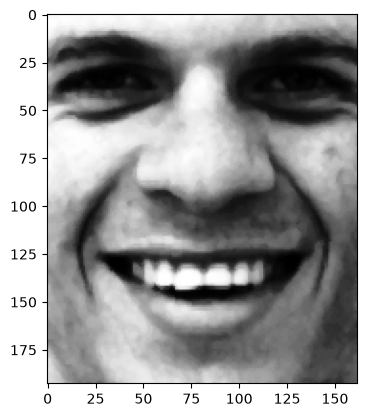

Mulher


In [11]:
# Perceptron com 2 componentes principais

svd_2c = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
svd_2c.fit(matrix)

dados_treino_2c = svd_2c.transform(fotos_treino_gen)
dados_val_2c = svd_2c.transform(fotos_val_gen)

clf_genero_2c = Perceptron(random_state=RANDOM_STATE)
clf_genero_2c.fit(dados_treino_2c, labels_treino_gen)

predicoes_val = clf_genero_2c.predict(dados_val_2c)
print(f"Acurácia (2 componentes): {accuracy_score(labels_val_gen, predicoes_val):.2%}")

# Demonstração em uma foto fora do conjunto rotulado
dados_teste_2c = svd_2c.transform(fotos_teste)
predicao_demo = clf_genero_2c.predict(dados_teste_2c)
a = random.randint(0, len(fotos_teste) - 1)
plotar_foto(fotos_teste[a, :])
print('Mulher' if predicao_demo[a] == 1 else 'Homem')

Acurácia (sorriso, 2 componentes, conjunto de validação): 70.00%


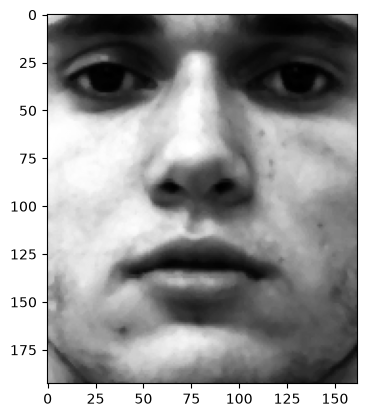

Neutro


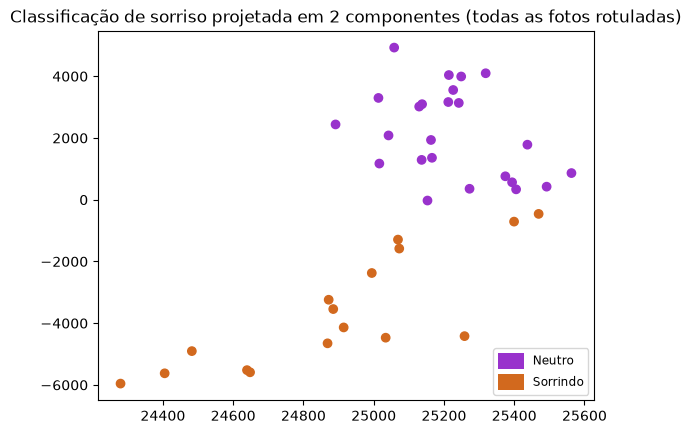

In [ ]:
# Classificador de sorriso
# fotos_treinamento alterna foto neutra / sorrindo para a mesma pessoa
labels_sorriso = np.array([-1 if i % 2 == 0 else 1 for i in range(fotos_treinamento.shape[0])])

fotos_treino_sor, fotos_val_sor, labels_treino_sor, labels_val_sor = train_test_split(
    fotos_treinamento, labels_sorriso, test_size=0.25,
    stratify=labels_sorriso, random_state=RANDOM_STATE
)

dados_treino_sor = svd_2c.transform(fotos_treino_sor)
dados_val_sor = svd_2c.transform(fotos_val_sor)

clf_sorriso = Perceptron(random_state=RANDOM_STATE)
clf_sorriso.fit(dados_treino_sor, labels_treino_sor)

predicoes_val = clf_sorriso.predict(dados_val_sor)
print(f"Acurácia (sorriso, 2 componentes, conjunto de validação): {accuracy_score(labels_val_sor, predicoes_val):.2%}")

# Exibindo uma foto de validação e sua previsão
a = random.randint(0, len(fotos_val_sor) - 1)
plotar_foto(fotos_val_sor[a, :])
print('Sorrindo' if predicoes_val[a] == 1 else 'Neutro')

# Projetando e classificando TODAS as fotos rotuladas (treino + validação) para o gráfico,
# assim o scatter mostra o conjunto completo em vez de só a fatia de validação (~25% dos pontos)
dados_completos_sor = svd_2c.transform(fotos_treinamento)
predicoes_completas = clf_sorriso.predict(dados_completos_sor)

x, y = dados_completos_sor.T
c = ['darkorchid' if g == -1 else 'chocolate' for g in predicoes_completas]

neutro_patch = mpatches.Patch(facecolor='darkorchid', label='Neutro')
sorrindo_patch = mpatches.Patch(facecolor='chocolate', label='Sorrindo')

plt.legend(handles=[neutro_patch, sorrindo_patch], loc=4, fontsize='small',
           handleheight=1.7, handlelength=2.2)
plt.scatter(x, y, c=c)
plt.title('Classificação de sorriso projetada em 2 componentes')
plt.show()

Coeficientes da foto neutra: [ -730.55741959  -267.07502635 -2466.44078752 -4625.41139018
  1540.34317458   395.36435443   297.43545873   107.0204479
  1512.82638468  1695.11836296]
Coeficientes da foto sorrindo: [ -711.69349539  -448.17222652 -2345.83830032 -4626.01511218
  1380.67605386   330.98580571    69.6326162    300.2471419
  1386.62520543  1625.75036132]


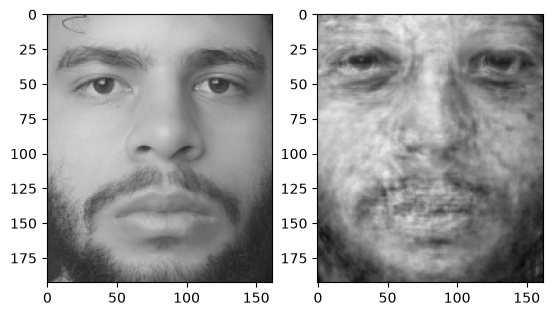

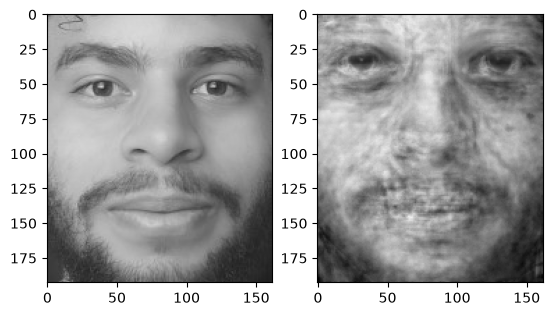

In [13]:
"""Trazendo minhas fotos para as variáveis"""

MY_IMAGES = r"Imagens/Minhas fotos"

minhas_fotos = np.empty([2, IMAGE_HEIGHT * IMAGE_WIDTH])

neutro = Image.open(f'{MY_IMAGES}/{str(1)}a.jpg').convert('L')
foto_neutro = np.asarray(neutro).ravel()
    
sorrindo = Image.open(f'{MY_IMAGES}/{str(1)}b.jpg').convert('L')
foto_sorrindo = np.asarray(sorrindo).ravel()

#############################################################################################################

# Obtendo as diferenças da imagem média
dif_neutro = foto_neutro - im_media
dif_sorrindo = foto_sorrindo - im_media

svd = TruncatedSVD(n_components=400)
svd.fit(matrix) # Obtendo as 400 componentes

coef_neutro = dif_neutro @ svd.components_.T # Coeficientes da foto neutro
coef_sorrindo = dif_sorrindo @ svd.components_.T # Coeficientes da foto sorrindo

print(f"Coeficientes da foto neutra: {coef_neutro[:10]}") 
print(f"Coeficientes da foto sorrindo: {coef_sorrindo[:10]}")

# Projeções feitas com todos os coeficientes, para que a projeção seja com 10 componentes basta usar um slice
proj_neutro = (coef_neutro @ svd.components_) + im_media
proj_sorrindo = (coef_sorrindo @ svd.components_) + im_media

# Exibindo as fotos e suas projeções usando todas as componentes
plotar_fotos(foto_neutro, proj_neutro)
plotar_fotos(foto_sorrindo, proj_sorrindo)

# Relato do experimento

Este notebook aplica **Álgebra Linear Computacional** — mais especificamente **Decomposição em Valores Singulares (SVD)** — para analisar um banco de fotos de rosto e treinar classificadores simples sobre elas. A ideia central é: uma imagem é só um vetor de números (intensidade de cada pixel), e o SVD encontra as direções (componentes principais) que melhor explicam as variações entre essas fotos, permitindo representar cada imagem com muito menos números do que o total de pixels.

## 1. Imagem média (Passo 2)

A primeira etapa calcula a **imagem média** de todo o banco de fotos, somando os vetores de pixel de todas as imagens e dividindo pelo total. O resultado é um "rosto médio" borrado, mas revelador: regiões que variam pouco entre as pessoas (como a posição dos olhos) ficam nítidas na média, enquanto regiões que variam mais (como a boca, por conta de expressões sérias vs. sorrindo) ficam mais borradas. Isso já é uma pista visual de onde está a maior parte da "informação" que diferencia uma foto da outra.

## 2. Centralização e SVD (Passos 3 e 4)

Antes de aplicar o SVD, subtraímos a imagem média de cada foto (`M = matrix - im_media`). Esse passo é chamado de **centralização dos dados** e é importante porque o SVD identifica direções de variação em torno da origem — sem centralizar, as componentes captariam parte do "rosto médio" em vez de captar só as diferenças entre as fotos.

Com `k = 5` componentes principais, reconstruímos algumas fotos e comparamos com o original. O resultado não é uma cópia perfeita: com apenas 5 das centenas de componentes disponíveis, só as variações mais fortes do banco de dados são capturadas, então detalhes finos de cada rosto individual se perdem. Isso ilustra bem a ideia de **compressão com perdas**: quanto menos componentes, mais informação específica de cada foto é sacrificada em troca de uma representação mais compacta.

## 3. Classificadores (Passos 6 e 7)

Aqui usamos um **Perceptron** (classificador linear simples) para prever gênero e expressão facial (sorrindo ou neutro), a partir das coordenadas de cada foto no espaço reduzido do SVD.

**Gênero — 2 vs. 3 componentes:** o classificador com apenas 2 componentes principais tem pouquíssima informação para separar as classes, e a acurácia medida no conjunto de validação reflete isso (número exibido na célula correspondente). Com 3 componentes o classificador já tem mais dimensões para traçar uma fronteira de decisão razoável, e a acurácia tende a ser mais alta — mas vale lembrar que ainda é pouca informação: 2 ou 3 componentes representam uma fração pequena da variância total das imagens.

**Sorriso — 2 componentes:** a diferença entre "boca aberta sorrindo" e "boca fechada séria" é uma das maiores fontes de variação visual entre as fotos de uma mesma pessoa, então mesmo com poucas componentes o classificador consegue separar bem as duas classes. O gráfico de dispersão mostra a projeção de todas as fotos rotuladas nas 2 componentes, coloridas pela previsão do modelo — dá pra ver visualmente os dois grupos formando aglomerados razoavelmente separados.

*(Observação: as acurácias exatas ficam registradas na saída de cada célula ao rodar o notebook; depois de rodar, vale substituir esta observação pelos números reais e comentar se bateram com o esperado.)*

## 4. Reconstrução com muitas componentes (Passo 5)

Por fim, projetamos duas fotos próprias (uma neutra, uma sorrindo) usando as 400 componentes principais do banco de dados. Como o número de componentes usadas aqui é muito maior que nos passos anteriores, a reconstrução fica visualmente muito mais próxima da foto original — o que confirma a relação central do experimento: **quanto mais componentes principais, mais fiel a reconstrução, ao custo de precisar de mais números para representar cada imagem.** Testes com poucas componentes (ex: 10) mostravam reconstruções bem mais borradas, o que reforça esse equilíbrio entre compressão e fidelidade.

## Conclusão

O experimento mostra, na prática, como o SVD permite comprimir um banco de imagens em um espaço de poucas dimensões sem perder toda a informação relevante, e como esse espaço reduzido já é suficiente para tarefas simples de classificação (gênero, expressão facial). A escolha do número de componentes é sempre um equilíbrio entre economia de representação e capacidade de discriminar/reconstruir detalhes.